In [1]:
import numpy as np
import pandas as pd
from copy import deepcopy
from pathlib import Path
import torch
from torch import nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
import torch_geometric as tg
from torch.nn import functional as F
from captum.attr import IntegratedGradients

from cardioverse.configs.gnn_config import GNNModelConfig, TrainingConfig
from cardioverse.configs.fusion_config import FusionModelConfig, FusionTrainingConfig
from cardioverse.models.linet import LiNetModel
from cardioverse.models.fusion import GNNIntegrativeModel
from cardioverse.training.gnn_trainer import GNNTrainer
from cardioverse.training.fusion_trainer import GNNFusionTrainer

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle

from tqdm import tqdm
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Load gene level data
X1 = pd.read_csv("../data/gene_level_data/X.csv", index_col=0)
edge_index1 = np.load("../data/gene_level_data/edge_index.npy")

# Load reaction level data
X2 = pd.read_csv("../data/reaction_level_data/X.csv", index_col=0)
edge_index2 = np.load("../data/reaction_level_data/edge_index.npy")

# get feature names
genes = list(X1.columns)
reactions = list(X2.columns)

# align samples 
X2 = X2.loc[X1.index]

# Load metadata
drug_metadata = pd.read_csv("../data/metadata/drug_metadata.csv")

print(f"Gene data shape: {X1.shape}")
print(f"Reaction data shape: {X2.shape}")
print(f"Samples: {X1.index.tolist()[:5]}...")
print(f"Genes: {genes[:5]}...")
print(f"Reactions: {reactions[:5]}...")

Gene data shape: (299, 916)
Reaction data shape: (299, 3572)
Samples: ['MSN01:afatinib', 'MSN02:afatinib', 'MSN05:afatinib', 'MSN06:afatinib', 'MSN08:afatinib']...
Genes: ['GNB1', 'PRKCZ', 'PIK3CD', 'MTOR', 'AGTRAP']...
Reactions: ['RCR10001', 'RCR10002', 'RCR10004', 'RCR10005', 'RCR10006']...


In [4]:
# Set up labels from metadata
drug_tox = drug_metadata.set_index("Drug name")["Is_cardiotoxic"]
drug_tox = drug_tox.map({"Yes": 1, "No": 0, "ND": -1})
drug_tox = drug_tox[drug_tox != -1]

# Get sample names from data index
sample_names = X1.index.tolist()

# Filter to samples with labels
mask = [name.split(":")[1] in drug_tox.index for name in sample_names]
X1 = X1.loc[mask]
X2 = X2.loc[mask]
sample_ids = list(X1.index)

# set up labels
y = np.array([drug_tox[name.split(":")[-1]] for name in sample_ids]).astype(np.int64)

# split by drugs 
unique_drugs = list(drug_tox.index)
drug_labels = list(drug_tox.values)
train_drugs, val_drugs, _, _ = train_test_split(
    unique_drugs, drug_labels, test_size=0.3, stratify=drug_labels, random_state=0
)
train_mask = [v.split(":")[-1] in train_drugs for v in X1.index]
val_mask = [v.split(":")[-1] in val_drugs for v in X1.index]
X1_train = X1.loc[train_mask].values
X2_train = X2.loc[train_mask].values
X1_val = X1.loc[val_mask].values
X2_val = X2.loc[val_mask].values
y_train = y[train_mask]
y_val = y[val_mask]
train_sample_ids = X1.loc[train_mask].index
val_sample_ids = X1.loc[val_mask].index
print(f'Train samples: {len(X1_train)}')
print(f'Val samples: {len(X1_val)}')

Train samples: 125
Val samples: 53


## Set up GNNs - pretrain each modality individually

In [5]:
modalities = {0: "genes", 1: "reactions"}
models = {}
histories = {}
X_trains = [X1_train, X2_train]
X_vals = [X1_val, X2_val]
edge_indices = [edge_index1, edge_index2]

In [6]:
# Training hyperparameters
num_layers = 3
hidden_dim = 100
dropout = 0.5
batch_size = 64
nepochs = 250
lr = 5e-4
lmbda_l1 = 1e-3
lmbda_l2 = 1e-3

print("-" * 60)
print("PRETRAINING PHASE")
print("-" * 60)
for idx, modality in modalities.items():
    print(f"** Pretraining GNN for {modality} modality **")

    # Create datasets
    X_train = torch.from_numpy(X_trains[idx]).float()
    X_val = torch.from_numpy(X_vals[idx]).float()
    train_dataset = TensorDataset(
        X_train, torch.from_numpy(y_train).long(), torch.arange(len(X_train))
    )
    val_dataset = TensorDataset(
        X_val, torch.from_numpy(y_val).long(), torch.arange(len(X_val))
    )

    # Set up configs, model and trainer
    model_config = GNNModelConfig(
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
        num_nodes=X_train.shape[1],
    )
    train_config = TrainingConfig(
        batch_size=batch_size, nepochs=nepochs, lr=lr, lmbda_l1=lmbda_l1, lmbda_l2=lmbda_l2
    )
    model = LiNetModel(model_config)
    optimizer = optim.Adam(model.parameters(), lr=train_config.lr)
    trainer = GNNTrainer(model, optimizer, torch.from_numpy(edge_indices[idx]).long())

    # Pretrain
    histories[idx] = trainer.fit(train_dataset, val_dataset, train_config)

    # Store the best model
    models[idx] = deepcopy(trainer.model).to("cpu")

------------------------------------------------------------
PRETRAINING PHASE
------------------------------------------------------------
** Pretraining GNN for genes modality **
[ Epoch 1 ] : loss: 0.743; val_loss: 0.664; acc: 0.456; val_acc: 0.788; f1: 0.456; val_f1: 0.781; auroc: 0.478; val_auroc: 0.818
[ Epoch 50 ] : loss: 0.581; val_loss: 0.517; acc: 0.632; val_acc: 0.788; f1: 0.584; val_f1: 0.781; auroc: 0.764; val_auroc: 0.910
[ Epoch 100 ] : loss: 0.572; val_loss: 0.508; acc: 0.664; val_acc: 0.808; f1: 0.630; val_f1: 0.806; auroc: 0.807; val_auroc: 0.809
[ Epoch 150 ] : loss: 0.508; val_loss: 0.515; acc: 0.713; val_acc: 0.808; f1: 0.695; val_f1: 0.803; auroc: 0.818; val_auroc: 0.699
[ Epoch 200 ] : loss: 0.438; val_loss: 0.775; acc: 0.779; val_acc: 0.788; f1: 0.773; val_f1: 0.781; auroc: 0.849; val_auroc: 0.644
[ Epoch 250 ] : loss: 0.369; val_loss: 1.027; acc: 0.811; val_acc: 0.771; f1: 0.808; val_f1: 0.767; auroc: 0.876; val_auroc: 0.674
** Pretraining GNN for reactions mod

## Set up fusion model and trainer

In [7]:
# Set up model and trainer configs
fusion_model_config = FusionModelConfig(
    embed_dim=100,  # Must match hidden_dim from pretraining
    num_heads=4,
    dim_ff=100,
    num_layers=2,
    dropout=0.1,
    activation="gelu",
    num_labels=2,
)

fusion_train_config = FusionTrainingConfig(
    batch_size=64,
    nepochs_stage1=100,
    nepochs_stage2=200,
    lr_stage1=1e-5,
    lr_stage2=1e-5,
    lmbda_l1=1e-3,
    lmbda_l2=1e-3,
    lmbda_kl=50.0,
    logstep=50,
)

# Set up multiview datasets
X1_train_t = torch.from_numpy(X1_train).float()
X2_train_t = torch.from_numpy(X2_train).float()
y_train_t = torch.from_numpy(y_train).long()
X1_val_t = torch.from_numpy(X1_val).float()
X2_val_t = torch.from_numpy(X2_val).float()
y_val_t = torch.from_numpy(y_val).long()
train_dataset_mv = TensorDataset(X1_train_t, X2_train_t, y_train_t, torch.arange(len(X1_train_t)))
val_dataset_mv = TensorDataset(X1_val_t, X2_val_t, y_val_t, torch.arange(len(X1_val_t)))

# Set up fusion model and trainer
fusion_model = GNNIntegrativeModel(models=list(models.values()), model_config=fusion_model_config)
fusion_optimizer = torch.optim.Adam(fusion_model.parameters(), lr=fusion_train_config.lr_stage1)
fusion_trainer = GNNFusionTrainer(
                            fusion_model,
                            fusion_optimizer, 
                            edge_indices=[torch.from_numpy(e).long() for e in edge_indices],
                                )

# Train fusion
fusion_history = fusion_trainer.fit(train_dataset_mv, val_dataset_mv, fusion_train_config)

/projects/compsci/karuturi/tripar/cardioverse-minimal/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[ Epoch 1 ] : loss: 0.779; val_loss: 0.681; acc: 0.508; val_acc: 0.500; f1: 0.357; val_f1: 0.338; auroc: 0.571; val_auroc: 0.930
[ Epoch 50 ] : loss: 0.598; val_loss: 0.622; acc: 0.723; val_acc: 0.808; f1: 0.713; val_f1: 0.803; auroc: 0.807; val_auroc: 0.687
[ Epoch 100 ] : loss: 0.501; val_loss: 0.644; acc: 0.773; val_acc: 0.789; f1: 0.771; val_f1: 0.785; auroc: 0.891; val_auroc: 0.698
[ Epoch 1 ] : loss: 0.499; val_loss: 0.646; acc: 0.796; val_acc: 0.789; f1: 0.794; val_f1: 0.785; auroc: 0.884; val_auroc: 0.694
[ Epoch 50 ] : loss: 0.404; val_loss: 0.737; acc: 0.829; val_acc: 0.495; f1: 0.829; val_f1: 0.463; auroc: 0.890; val_auroc: 0.708
[ Epoch 100 ] : loss: 0.343; val_loss: 0.830; acc: 0.806; val_acc: 0.476; f1: 0.805; val_f1: 0.438; auroc: 0.929; val_auroc: 0.689
[ Epoch 150 ] : loss: 0.318; val_loss: 0.863; acc: 0.830; val_acc: 0.495; f1: 0.830; val_f1: 0.463; auroc: 0.940; val_auroc: 0.695
[ Epoch 200 ] : loss: 0.315; val_loss: 0.830; acc: 0.822; val_acc: 0.808; f1: 0.823; val_

## Check training curve

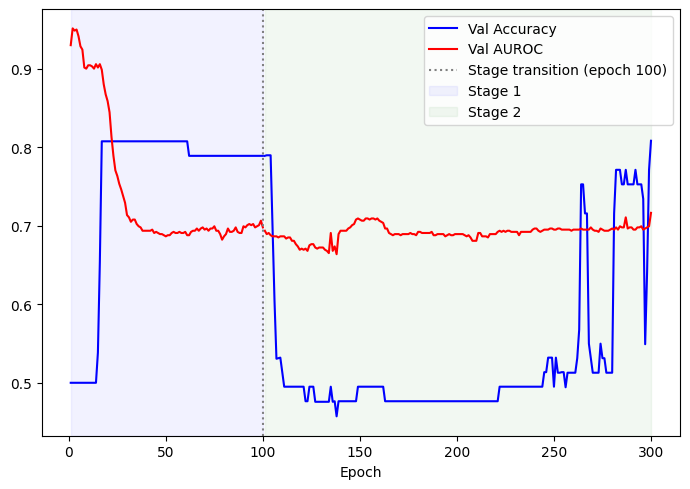

In [8]:
h1 = fusion_history[0]
h2 = fusion_history[1]
M1 = len(h1['val_acc'])
M2 = len(h2['val_acc'])
epochs_s1 = np.arange(1, M1 + 1)
epochs_s2 = np.arange(M1 + 1, M1 + M2 + 1)
fig, ax = plt.subplots(figsize=(7, 5))

# Stage 1
ax.plot(epochs_s1, h1['val_acc'],   color='blue', label='Val Accuracy')
ax.plot(epochs_s1, h1['val_auroc'], color='red',  label='Val AUROC')

# Stage 2
ax.plot(epochs_s2, h2['val_acc'],   color='blue', linestyle='-')
ax.plot(epochs_s2, h2['val_auroc'], color='red',  linestyle='-')

# Mark the transition
ax.axvline(x=M1, color='gray', linestyle=':', linewidth=1.5, label=f'Stage transition (epoch {M1})')

# Shade the two stages
ax.axvspan(1,      M1,      alpha=0.05, color='blue', label='Stage 1')
ax.axvspan(M1 + 1, M1 + M2, alpha=0.05, color='green', label='Stage 2')

ax.set_xlabel('Epoch')
ax.legend()
plt.tight_layout()
plt.show()

## Check confusion matrix 

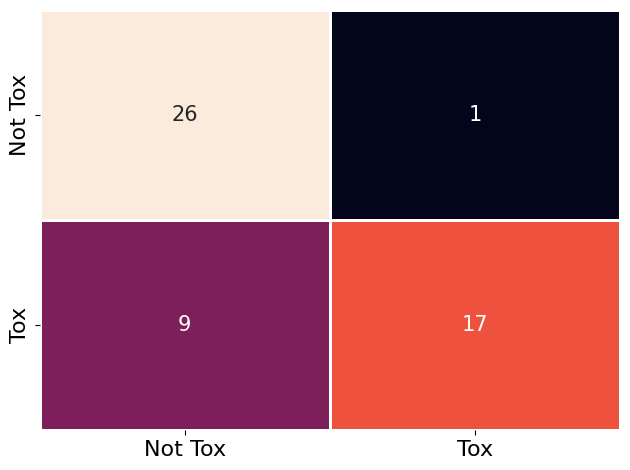

In [10]:
yval_true, yval_pred, val_ids = [], [], []
for batch in DataLoader(val_dataset_mv, batch_size=32, shuffle=False):
    *xs, y, ids = batch
    logits = fusion_trainer.predict(*xs)
    yval_pred.append(logits.detach().cpu().numpy().argmax(1))
    yval_true.append(y.detach().cpu().numpy())
    val_ids.append(ids.detach().cpu().numpy())

yval_true = np.hstack(yval_true)
yval_pred = np.hstack(yval_pred)
val_ids = np.hstack(val_ids)
valpred_df = pd.DataFrame(
    index=val_ids, data={"ytrue": yval_true, "ypred": yval_pred}
)
correct_case_ids = valpred_df[(valpred_df.ytrue == 1) & (valpred_df.ytrue == valpred_df.ypred)].index.to_list()
correct_ctrl_ids = valpred_df[(valpred_df.ytrue == 0) & (valpred_df.ytrue == valpred_df.ypred)].index.to_list()

confmat_val = confusion_matrix(yval_true, yval_pred)
confmat_val = pd.DataFrame(confmat_val, index=["Not Tox", "Tox"], columns=["Not Tox", "Tox"])

sns.heatmap(
    confmat_val, cbar=False, linewidths=2.0, annot=True, annot_kws={"fontsize": 15}, fmt="d"
)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

## Model explanations 

### Get integrated gradient scores 

In [11]:
model_forward = fusion_trainer.predict
ig = IntegratedGradients(model_forward)
feature_lists = {"genes": genes, "reactions": reactions}

# Get IG scores
res = {m: [] for _, m in modalities.items()}
ids = []
for sample in tqdm(val_dataset_mv, total=len(val_dataset_mv)):
    *xs, _, sample_id = sample
    ids.append(sample_id.detach().cpu().numpy().item())

    xs = tuple(x.unsqueeze(0).requires_grad_(True) for x in xs)
    _res = ig.attribute(xs, target=1)
    _res = [r.detach().cpu().numpy() for r in _res]

    for j, (idx, m) in enumerate(modalities.items()):
        res[m].append(_res[j])
res = {m: np.vstack(v) for m, v in res.items()}

# Put together DataFrames
igdf = {
    m: pd.DataFrame(res[m], index=ids, columns=feature_lists[m])
    for idx, m in modalities.items()
}

igtox = {m: df.loc[correct_case_ids] for m, df in igdf.items()}
ignontox = {m: df.loc[correct_ctrl_ids] for m, df in igdf.items()}

# Multiple hypothesis testing for identifying informative features
inff_df = {}
for idx, m in modalities.items():
    pvals = []
    for feat in igtox[m].columns:
        stat, p = mannwhitneyu(
            igtox[m][feat], ignontox[m][feat], alternative="two-sided"
        )
        pvals.append(p)

    reject, pvals_adj, _, _ = multipletests(pvals, method="fdr_bh")

    inff_df[m] = (
        pd.DataFrame(
            {
                "feature": igtox[m].columns,
                "pval": pvals,
                "pval_adj": pvals_adj,
                "-log10padj": -np.log10(pvals_adj),
                "reject": reject,
                "mean_tox": igtox[m].mean(),
                "mean_nontox": ignontox[m].mean(),
                "mean_diff": igtox[m].mean() - ignontox[m].mean(),
            }
        )
        .set_index("feature")
        .sort_values("pval_adj")
    )

100%|███████████████████████████████████████████████████████████████████████| 53/53 [00:07<00:00,  7.00it/s]


### Differential attruibution analysis to identify important features 

In [12]:
# Multiple hypothesis testing for identifying informative features
inff_df = {}
for idx, m in modalities.items():
    pvals = []
    for feat in igtox[m].columns:
        stat, p = mannwhitneyu(
            igtox[m][feat], ignontox[m][feat], alternative="two-sided"
        )
        pvals.append(p)

    reject, pvals_adj, _, _ = multipletests(pvals, method="fdr_bh")

    inff_df[m] = (
        pd.DataFrame(
            {
                "feature": igtox[m].columns,
                "pval": pvals,
                "pval_adj": pvals_adj,
                "-log10padj": -np.log10(pvals_adj),
                "reject": reject,
                "mean_tox": igtox[m].mean(),
                "mean_nontox": ignontox[m].mean(),
                "mean_diff": igtox[m].mean() - ignontox[m].mean(),
            }
        )
        .set_index("feature")
        .sort_values("pval_adj")
    )

### Get top 20 genes 

In [13]:
top20_genes_df = inff_df["genes"].head(20)
top20_genes_df = (
    top20_genes_df.loc[:, ["pval_adj"]]
    .reset_index()
    .rename(columns={"index": "gene"})
)
top20_genes_df.index = top20_genes_df.index + 1
display(
    top20_genes_df.style.format({"pval_adj": "{:.2e}"}).set_table_styles(
        [
            {"selector": "table", "props": [("border", "2px solid black"), ("border-collapse", "collapse")]},
            {"selector": "th", "props": [("border", "1.5px solid black"), ("padding", "6px"), ("text-align", "left")]},
            {"selector": "td", "props": [("border", "1px solid #777"), ("padding", "6px")]},
        ]
    )
)

,feature,pval_adj
1,SLC8A1,2.09e-06
2,ERBB2,2.09e-06
3,ATP5F1E,2.09e-06
4,CYFIP1,2.09e-06
5,PIK3R1,2.09e-06
6,SSRP1,2.09e-06
7,TOMM22,2.09e-06
8,PRKAB2,2.09e-06
9,HSP90AB1,2.09e-06
10,FTH1,2.09e-06


### Get top 20 reactions 

In [17]:
top20_reactions_df = inff_df["reactions"].head(20)
reactions_meta_df = pd.read_csv("../data/metadata/reactions_metadata.csv")
top20_reactions_df = \
        pd.concat(
            [
                top20_reactions_df, 
                reactions_meta_df.set_index("Abbreviation").loc[top20_reactions_df.index].loc[:,["Description", "Subsystem"]]
            ], 
            axis=1)
pd.options.display.float_format = "{:.2e}".format
top20_reactions_df

,pval,pval_adj,-log10padj,reject,mean_tox,mean_nontox,mean_diff,Description,Subsystem
feature,,,,,,,,,
RCR11596,7.40e-08,1.89e-05,4.72e+00,True,-3.54e-04,2.45e-06,-3.57e-04,"1,2-alpha-mannosyl-oligosaccharide alpha-D-man...",Glycan metabolism
RCR11108,6.41e-08,1.89e-05,4.72e+00,True,-4.10e-02,-3.51e-04,-4.06e-02,ATP:D-Gluconate 6-phosphotransferase,Pentose phosphate pathway
RCR41025,7.40e-08,1.89e-05,4.72e+00,True,8.58e-03,-2.07e-05,8.60e-03,H+ / Na+ antiport [cs~cs],Transport
RCR14284,7.40e-08,1.89e-05,4.72e+00,True,8.82e-05,1.65e-07,8.80e-05,L-Ornithine:2-oxo-acid aminotransferase,Arginine and proline metabolism
RCR13371,6.41e-08,1.89e-05,4.72e+00,True,4.65e-04,5.31e-06,4.60e-04,"alpha-N-acetylglucosaminyltransferase I, Golgi...",Proteoglycan metabolism
RCR14267,5.56e-08,1.89e-05,4.72e+00,True,-6.92e-02,-5.54e-04,-6.87e-02,exodeoxyribonuclease III[c],Nucleotide metabolism
RCR11197,5.56e-08,1.89e-05,4.72e+00,True,-6.56e-02,-5.25e-04,-6.50e-02,exodeoxyribonuclease III,Nucleotide metabolism
RCR13159,7.40e-08,1.89e-05,4.72e+00,True,2.26e-03,1.50e-05,2.25e-03,CDP-diacylglycerol:phosphatidylglycerol 3-phos...,Glycerolipid metabolism
RCR11266,6.41e-08,1.89e-05,4.72e+00,True,1.39e-02,-5.34e-05,1.39e-02,L-ornithine carboxy-lyase (putrescine-forming),Arginine and proline metabolism
